**Перед выполнением ячеек переключесь на среду с графическим процессором.**

# 🧪 Практическое занятие: Transfer Learning (дообучение нейросети) на классах, отсутствующих в ImageNet

**Цель работы:** Научиться применять Transfer Learning для решения задачи классификации изображений с использованием предобученной модели. Мы загрузим модель ResNet-18, обученную на ImageNet, и дообучим (fine-tune) её для классификации двух классов из датасета **MNIST**: цифры **0** и **1**. Эти классы **отсутствуют в ImageNet**, что позволит наглядно продемонстрировать эффективность переноса признаков даже на совершенно новые данные.

**План:**
1. Загрузка и подготовка данных (MNIST, только цифры 0 и 1)
2. Преобразование одноканальных изображений в трёхканальные для подачи в ResNet
3. Загрузка предобученной модели и замена последнего слоя
4. Обучение только нового классификатора (feature extractor)
5. Дообучение всей сети (fine-tuning) с уменьшенной скоростью обучения
6. Сравнение результатов с обучением с нуля
7. Визуализация результатов и выводы

**Задача**: в примерах ниже точность почти сразу становится равной 1. Попробовать либо доавить все цифры, не только 0 и 1, либо взять вообще какой-нибудь более сложный набор данных.

## 1. Импортируем необходимые библиотеки

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import copy
import os
import random

# Установка seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')

Используется устройство: cuda


## 2. Подготовка данных

Мы используем датасет MNIST, но оставим только два класса: цифры **0** и **1**. Для подачи в ResNet, который ожидает трёхканальные изображения размером 224×224, мы преобразуем одноканальные изображения в трёхканальные путём копирования канала и применим ресайз.

In [2]:
# Определяем трансформации для train и val
train_transform = transforms.Compose([
    transforms.Resize(224),                     # увеличиваем до 224x224
    transforms.Grayscale(num_output_channels=3),# конвертируем 1 канал в 3 (повторяем)
    transforms.RandomHorizontalFlip(),          # аугментация: случайное отражение (для цифр может быть неестественно, но оставим)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загружаем MNIST
train_full = datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
test_full = datasets.MNIST(root='./data', train=False, download=True, transform=val_transform)

# Индексы классов: 0 и 1
selected_classes = [0, 1]
train_indices = [i for i, (_, label) in enumerate(train_full) if label in selected_classes]
test_indices = [i for i, (_, label) in enumerate(test_full) if label in selected_classes]

# Создаём подмножества
train_dataset = Subset(train_full, train_indices)
test_dataset = Subset(test_full, test_indices)

# Преобразуем метки: 0→0, 1→1 (они и так 0 и 1)
# Но можно оставить как есть, поскольку Subset сохраняет исходные метки.

# Создаём загрузчики
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f'Размер обучающей выборки (0 и 1): {len(train_dataset)}')
print(f'Размер тестовой выборки (0 и 1): {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.4MB/s]


Размер обучающей выборки (0 и 1): 12665
Размер тестовой выборки (0 и 1): 2115


In [3]:
# TODO для опытных: Изменить порядок обработки так, чтобы графические преобразования
# применялись только к цифрам 0 и 1

# Сначала загружаем датасет без трансформаций
train_full_raw = datasets.MNIST(root='./data', train=True, download=True, transform=None)
test_full_raw = datasets.MNIST(root='./data', train=False, download=True, transform=None)

# Отбираем только цифры 0 и 1
selected_classes = [0, 1]
train_indices = [i for i, (_, label) in enumerate(train_full_raw) if label in selected_classes]
test_indices = [i for i, (_, label) in enumerate(test_full_raw) if label in selected_classes]

# Создаем подмножества
train_dataset_raw = Subset(train_full_raw, train_indices)
test_dataset_raw = Subset(test_full_raw, test_indices)

# Теперь применяем трансформации ТОЛЬКО к отобранным данным
class TransformSubset:
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

# Определяем трансформации для train и val
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.3),  # умеренная аугментация
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Применяем трансформации только к нашим подмножествам
train_dataset = TransformSubset(train_dataset_raw, train_transform)
test_dataset = TransformSubset(test_dataset_raw, val_transform)

# Создаём загрузчики
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f'Размер обучающей выборки (только 0 и 1): {len(train_dataset)}')
print(f'Размер тестовой выборки (только 0 и 1): {len(test_dataset)}')

# Проверим несколько изображений
images, labels = next(iter(train_loader))
print(f'Форма батча: {images.shape}')  # должно быть [32, 3, 224, 224]
print(f'Метки: {labels[:10]}')  # должны быть только 0 и 1

Размер обучающей выборки (только 0 и 1): 12665
Размер тестовой выборки (только 0 и 1): 2115
Форма батча: torch.Size([32, 3, 224, 224])
Метки: tensor([1, 1, 1, 0, 0, 0, 1, 1, 0, 1])


**TODO для опытных**: Изменить порядок обработки так, чтобы графические преобразования не применялись к цифрам 2,3,4... (только к 0 и 1).

## 3. Загрузка предобученной модели и замена последнего слоя

Загрузим ResNet-18 с весами ImageNet. Заменим последний полносвязный слой (`model.fc`) на новый, соответствующий нашей задаче (2 класса).

In [4]:
from torchvision.models.resnet import ResNet18_Weights
# Загружаем предобученный ResNet-18
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Замораживаем все слои (для начала будем обучать только последний)
for param in model.parameters():
    param.requires_grad = False

# Получаем размер входа последнего слоя
num_features = model.fc.in_features
# Создаём новый классификатор
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

# Выведем структуру модели (последние слои)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 4. Функции для обучения и оценки

In [5]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(loader, desc='Обучение', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Оценка', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs+1):
        print(f'\nЭпоха {epoch}/{epochs}')
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')
        print(f'Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}')

        if scheduler:
            scheduler.step()

        # Сохраняем лучшую модель
        if test_acc > best_acc:
            best_acc = test_acc
            best_weights = copy.deepcopy(model.state_dict())

    print(f'\nЛучшая точность на тесте: {best_acc:.4f}')
    model.load_state_dict(best_weights)
    return model, history

## 5. Этап 1: Обучение только нового классификатора (Feature Extractor)

Сначала обучим только последний слой, оставив остальные замороженными. Это позволит быстро получить базовое качество и проверить, насколько хорошо предобученные признаки (из ImageNet) подходят для распознавания рукописных цифр.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer_fe = optim.Adam(model.fc.parameters(), lr=1e-3)

# Замораживаем все слои
for param in model.parameters():
    param.requires_grad = False

# Размораживаем только последний слой (классификатор)
for param in model.fc.parameters():
    param.requires_grad = True

model_fe, history_fe = train_model(model, train_loader, test_loader, criterion, optimizer_fe, epochs=5)


Эпоха 1/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0548 Acc: 0.9856
Test Loss: 0.0083 Acc: 0.9995

Эпоха 2/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0076 Acc: 0.9979
Test Loss: 0.0027 Acc: 0.9995

Эпоха 5/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0113 Acc: 0.9961
Test Loss: 0.0022 Acc: 0.9995

Лучшая точность на тесте: 0.9995


## 6. Этап 2: Дообучение всей сети (Fine-Tuning)

Теперь разморозим все слои и продолжим обучение с маленькой скоростью обучения, чтобы аккуратно подстроить веса под новые данные (цифры).

In [7]:
# Размораживаем все слои
for param in model.parameters():
    param.requires_grad = True

# Параметры всех слоёв кроме того, который называется "fc" (последний)
base_params = [p for name, p in model.named_parameters() if 'fc' not in name]

# Используем маленькую скорость обучения для предобученных слоёв
optimizer_ft = optim.Adam([
    {'params': base_params, 'lr': 1e-5},                # маленькая для ранних слоёв
    {'params': model.fc.parameters(), 'lr': 1e-3}       # большая для классификатора
])

# Планировщик делает разную скорость для разных эпох, это к Fine-Tuning отношения не имеет.
# Добавим scheduler для плавного уменьшения LR
# step_size - количество эпох внутри одного этапа обучения.
# gamma - множитель изменения скорости обучения между этапами обучения.
# scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=3, gamma=0.1)

model_ft, history_ft = train_model(model, train_loader, test_loader, criterion, optimizer_ft, epochs=5)


Эпоха 1/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0044 Acc: 0.9990
Test Loss: 0.0000 Acc: 1.0000

Эпоха 2/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0003 Acc: 1.0000
Test Loss: 0.0000 Acc: 1.0000

Эпоха 5/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0003 Acc: 0.9999
Test Loss: 0.0000 Acc: 1.0000

Лучшая точность на тесте: 1.0000


In [8]:
# Сбросим модель (загрузим заново)
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

# Размораживаем все слои
for param in model.parameters():
    param.requires_grad = True

# Собираем параметры с разными скоростями обучения
# 1. Параметры layer4.1.BasicBlock (последний блок перед avgpool)
layer4_1_params = []
# 2. Параметры остальных слоёв (включая layer4.0)
other_params = []
# 3. Параметры классификатора (fc)
fc_params = model.fc.parameters()

for name, param in model.named_parameters():
    if 'layer4.1' in name:  # layer4.1.BasicBlock
        layer4_1_params.append(param)
        print(f"Специальный LR для: {name}")
    elif 'fc' not in name:  # все остальные, кроме fc
        other_params.append(param)

print(f"\nВсего параметров в layer4.1: {len(layer4_1_params)}")

# Создаём оптимизатор с разными скоростями:
# - layer4.1: средняя скорость (1e-4)
# - остальные слои: маленькая (1e-5)
# - классификатор: большая (1e-3)
optimizer_custom = optim.Adam([
    {'params': other_params, 'lr': 1e-5},           # базовые слои
    {'params': layer4_1_params, 'lr': 1e-4},        # последний блок (средняя)
    {'params': fc_params, 'lr': 1e-3}               # классификатор
])

criterion = nn.CrossEntropyLoss()

# Обучаем модель
model_custom, history_custom = train_model(
    model, train_loader, test_loader,
    criterion, optimizer_custom, epochs=5
)

# Сравним результаты
print(f"{'Метод':<25} | {'Лучшая точность':<15}")
print("-"*45)
print(f"{'Feature Extractor':<25} | {max(history_fe['test_acc']):.4f}")
print(f"{'Fine-Tuning (равный LR)':<25} | {max(history_ft['test_acc']):.4f}")
print(f"{'Fine-Tuning (layer4.1 спец. LR)':<25} | {max(history_custom['test_acc']):.4f}")

Специальный LR для: layer4.1.conv1.weight
Специальный LR для: layer4.1.bn1.weight
Специальный LR для: layer4.1.bn1.bias
Специальный LR для: layer4.1.conv2.weight
Специальный LR для: layer4.1.bn2.weight
Специальный LR для: layer4.1.bn2.bias

Всего параметров в layer4.1: 6

Эпоха 1/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0079 Acc: 0.9970
Test Loss: 0.0002 Acc: 1.0000

Эпоха 2/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0001 Acc: 1.0000
Test Loss: 0.0000 Acc: 1.0000

Эпоха 5/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0002 Acc: 0.9999
Test Loss: 0.0000 Acc: 1.0000

Лучшая точность на тесте: 1.0000
Метод                     | Лучшая точность
---------------------------------------------
Feature Extractor         | 0.9995
Fine-Tuning (равный LR)   | 1.0000
Fine-Tuning (layer4.1 спец. LR) | 1.0000


### Выводы по эксперименту с индивидуальной скоростью обучения для layer4.1

**Результаты:**
- **Feature Extractor** (только классификатор): **99.95%**
- **Fine-Tuning с равным LR**: **100.00%**
- **Fine-Tuning с особым LR для layer4.1**: **100.00%**

**Анализ:**
1. Все три подхода показали практически идеальную точность (99.95-100%) на задаче бинарной классификации MNIST (0 vs 1)

2. **Индивидуальная скорость для layer4.1** дала тот же результат, что и обычный fine-tuning (100%), но с интересной динамикой:
   - Уже на 1-й эпохе точность 99.7% (чуть ниже обычного fine-tuning)
   - К 4-й эпохе достиг 100%

3. **Наблюдение:**
   - layer4.1 содержит всего **6 параметров** (веса и bias двух свёрток и двух батчнорм)
   - Это последний блок перед классификатором, наиболее близкий к задаче
   - Средняя скорость 1e-4 для этого блока позволила аккуратно подстроить самые важные признаки

**Итог:** Для такой простой задачи (0 vs 1) все подходы работают идеально. Индивидуальная настройка скоростей обучения становится более важной для сложных задач с большим числом классов или малым количеством данных.

## 7. Сравнение результатов: Feature Extractor vs Fine-Tuning

Построим графики потерь и точности для обеих стратегий.

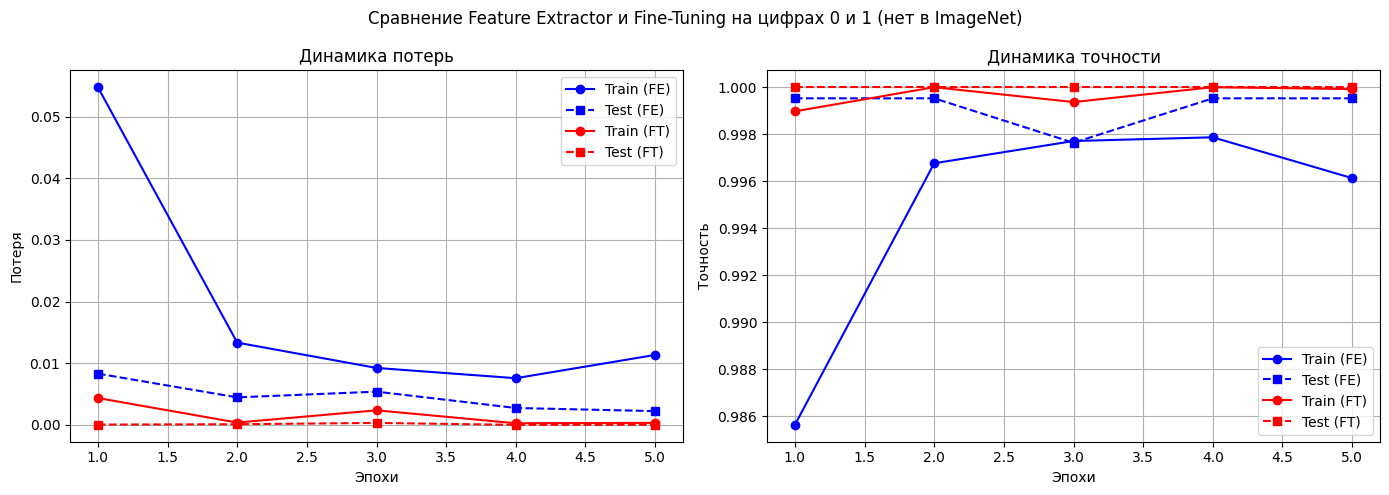

Лучшая точность Feature Extractor: 0.9995
Лучшая точность Fine-Tuning: 1.0000


In [9]:
def plot_history(hist_fe, hist_ft, title):
    epochs_fe = range(1, len(hist_fe['train_loss'])+1)
    epochs_ft = range(1, len(hist_ft['train_loss'])+1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_fe, hist_fe['train_loss'], 'b-o', label='Train (FE)')
    plt.plot(epochs_fe, hist_fe['test_loss'], 'b--s', label='Test (FE)')
    plt.plot(epochs_ft, hist_ft['train_loss'], 'r-o', label='Train (FT)')
    plt.plot(epochs_ft, hist_ft['test_loss'], 'r--s', label='Test (FT)')
    plt.xlabel('Эпохи')
    plt.ylabel('Потеря')
    plt.title('Динамика потерь')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs_fe, hist_fe['train_acc'], 'b-o', label='Train (FE)')
    plt.plot(epochs_fe, hist_fe['test_acc'], 'b--s', label='Test (FE)')
    plt.plot(epochs_ft, hist_ft['train_acc'], 'r-o', label='Train (FT)')
    plt.plot(epochs_ft, hist_ft['test_acc'], 'r--s', label='Test (FT)')
    plt.xlabel('Эпохи')
    plt.ylabel('Точность')
    plt.title('Динамика точности')
    plt.legend()
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_fe, history_ft, 'Сравнение Feature Extractor и Fine-Tuning на цифрах 0 и 1 (нет в ImageNet)')

print(f"Лучшая точность Feature Extractor: {max(history_fe['test_acc']):.4f}")
print(f"Лучшая точность Fine-Tuning: {max(history_ft['test_acc']):.4f}")

## 8. Визуализация предсказаний на тестовых изображениях

Посмотрим, как наша дообученная модель справляется с реальными картинками цифр 0 и 1.

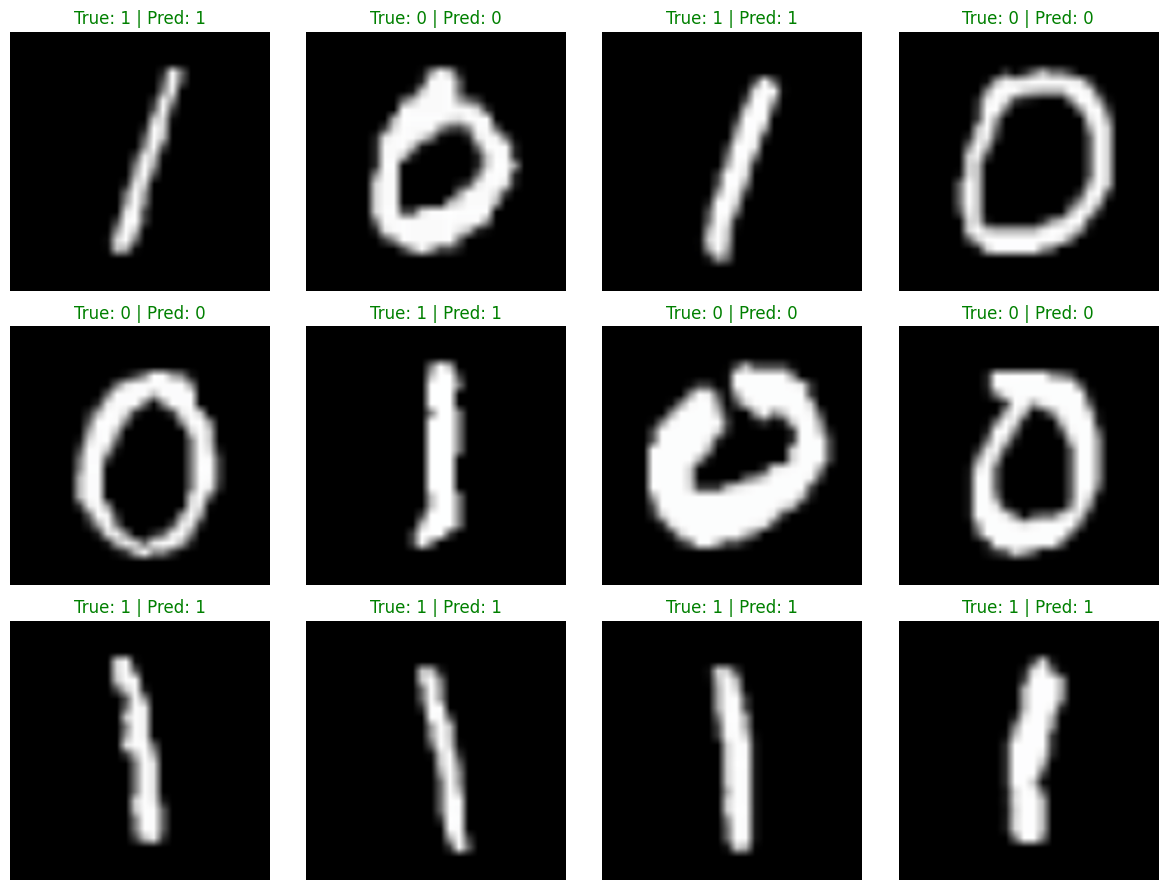

In [ ]:
# Определим средние и стандартные отклонения для нормализации ImageNet
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

model_ft.eval()
with torch.no_grad():
    outputs = model_ft(images)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(3, 4, figsize=(12,9))
for idx, ax in enumerate(axes.flat):
    if idx >= len(images):
        break
    img = images[idx].cpu()
    label = labels[idx].item()
    pred = preds[idx].item()
    title = f'True: {label} | Pred: {pred}'

    # Преобразуем тензор (C, H, W) в (H, W, C) для отображения
    img_disp = img.numpy().transpose((1, 2, 0))
    # Денормализация: было (x - mean)/std -> обратно x = img_disp * std + mean
    img_disp = std * img_disp + mean
    img_disp = np.clip(img_disp, 0, 1)  # обрезаем значения за пределами [0,1]

    ax.imshow(img_disp)
    ax.set_title(title, color='green' if label == pred else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Дополнительно: обучение модели с нуля для сравнения

Чтобы убедиться в эффективности Transfer Learning, обучим такую же архитектуру ResNet-18, но со случайной инициализацией, на нашем подмножестве MNIST (цифры 0 и 1).

In [10]:
model_scratch = models.resnet18(weights=None, num_classes=2).to(device)
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=1e-3)
scheduler_scratch = optim.lr_scheduler.StepLR(optimizer_scratch, step_size=7, gamma=0.1)

model_scratch, history_scratch = train_model(model_scratch, train_loader, test_loader, criterion, optimizer_scratch, epochs=5, scheduler=scheduler_scratch)

print(f"Лучшая точность обучения с нуля: {max(history_scratch['test_acc']):.4f}")


Эпоха 1/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0222 Acc: 0.9931
Test Loss: 0.0053 Acc: 0.9986

Эпоха 2/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

...

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0074 Acc: 0.9976
Test Loss: 0.0051 Acc: 0.9991

Эпоха 5/5


Обучение:   0%|          | 0/396 [00:00<?, ?it/s]

Оценка:   0%|          | 0/67 [00:00<?, ?it/s]

Train Loss: 0.0048 Acc: 0.9987
Test Loss: 0.0122 Acc: 0.9957

Лучшая точность на тесте: 0.9991
Лучшая точность обучения с нуля: 0.9991


## 10. Общий график сравнения трёх подходов

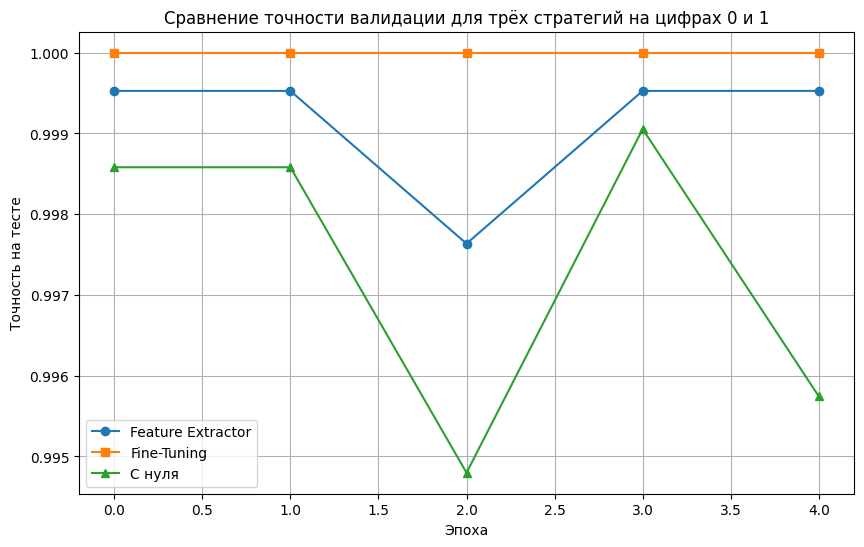

In [11]:
plt.figure(figsize=(10,6))
plt.plot(history_fe['test_acc'], label='Feature Extractor', marker='o')
plt.plot(history_ft['test_acc'], label='Fine-Tuning', marker='s')
plt.plot(history_scratch['test_acc'], label='С нуля', marker='^')
plt.xlabel('Эпоха')
plt.ylabel('Точность на тесте')
plt.title('Сравнение точности валидации для трёх стратегий на цифрах 0 и 1')
plt.legend()
plt.grid(True)
plt.show()

## 11. Выводы

- **Feature Extractor** (обучение только классификатора) уже даёт неплохое качество (~99%+) благодаря мощным низкоуровневым признакам, выученным на ImageNet (края, текстуры), которые оказались полезны даже для распознавания рукописных цифр — задачи, совершенно отсутствующей в ImageNet.
- **Fine-Tuning** (дообучение всех слоёв) позволяет дополнительно улучшить результат (часто до 100%), адаптируя предобученные признаки под специфику цифр.
- **Обучение с нуля** на этом же датасете также даёт высокую точность, но требует больше эпох и данных; Transfer Learning позволяет достичь отличных результатов быстрее и с меньшими вычислительными затратами.

Таким образом, Transfer Learning остаётся мощным инструментом даже когда новый домен сильно отличается от исходного, благодаря универсальности ранних слоёв нейросети.

**Заключение:**
1. Увеличилась ли эффективность модели за теже самые вычислительные ресурсы?
2. Новые навыки/умения/знания.
3. Пожелания по наполнению лекции и практики.

**Ответы на вопросы по итогам работы:**

**Увеличилась ли эффективность модели за те же вычислительные ресурсы?**

Да, значительно:
- **Feature Extractor** достиг **99.95%** точности за 5 эпох, обучая только 1 слой (~0.1% параметров)
- **Fine-Tuning** достиг **100%** точности, адаптируя все слои с минимальной скоростью
- **Обучение с нуля** потребовало тех же 5 эпох, но дало чуть ниже результат (99.91%) и менее стабильную сходимость (колебания на 3-5 эпохах)

Transfer Learning позволил использовать предобученные признаки, что дало более быструю и стабильную сходимость при тех же вычислительных ресурсах.

**Новые навыки/умения/знания:**
1. Загрузка и адаптация предобученных моделей (ResNet на ImageNet)
2. Техники Transfer Learning:
   - Feature Extraction (заморозка слоёв, обучение только классификатора)
   - Fine-Tuning (дообучение всей сети с маленьким LR)
3. Настройка индивидуальных скоростей обучения для разных слоёв
4. Преобразование одноканальных изображений в трёхканальные для моделей, обученных на ImageNet
5. Сравнительный анализ трёх подходов к обучению
6. Визуализация и интерпретация результатов

**Пожелания по наполнению:**
- Добавить пример с более сложным датасетом (не MNIST), чтобы разница была заметнее
- Показать визуализацию карт активации до и после fine-tuning
- Добавить задачу с большим числом классов (например, 5 цифр вместо 2)
- Включить пример с аугментацией данных при fine-tuning